# Supply Chain Delivery Delay Analytics

## Phase 3: Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to explore the cleaned supply chain dataset, identify patterns related to delivery delays, generate business insights, and provide actionable recommendations through data visualization.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
clean_data = pd.read_csv("../data/processed/supply_chain_cleaned.csv")
clean_data.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,...,Product Status,shipping date (DateOrders),Shipping Mode,Order Month,Order Day,Order Year,Shipping Month,Shipping Day,Delay Days,Delivery Performance
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,...,0,2018-02-03 22:56:00,Standard Class,February,Wednesday,2018,February,Saturday,-1,Early
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,...,0,2018-01-18 12:27:00,Standard Class,January,Saturday,2018,January,Thursday,1,Delayed
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,...,0,2018-01-17 12:06:00,Standard Class,January,Saturday,2018,January,Wednesday,0,On Time
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,Los Angeles,EE. UU.,...,0,2018-01-16 11:45:00,Standard Class,January,Saturday,2018,January,Tuesday,-1,Early
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,...,0,2018-01-15 11:24:00,Standard Class,January,Saturday,2018,January,Monday,-2,Early


In [5]:
clean_data.shape

(180519, 47)

In [6]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 47 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Name                  180519 non-null  object 
 8   Customer City                  180519 non-null  object 
 9   Customer Country               180519 non-null  object 
 10  Customer Segment               180519 non-null  object 
 11  Customer State                 180519 non-null  object 
 12  Department Name               

In [7]:
# Which Shipping Mode experiences the highest delivery delay?

shipping_delay = (
    clean_data
    .groupby("Shipping Mode")["Delay Days"]
    .mean()
    .sort_values(ascending=False)
)

shipping_delay

Shipping Mode
Second Class      1.990828
First Class       1.000000
Same Day          0.478279
Standard Class   -0.004093
Name: Delay Days, dtype: float64

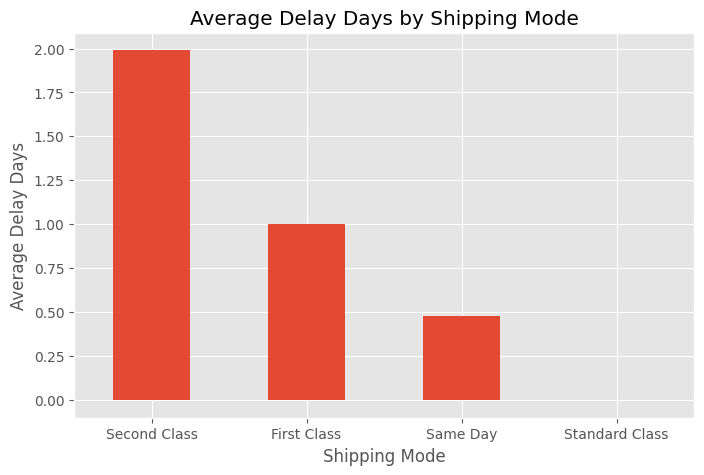

In [8]:
plt.figure(figsize=(8,5))

shipping_delay.plot(kind="bar")

plt.title("Average Delay Days by Shipping Mode")

plt.xlabel("Shipping Mode")

plt.ylabel("Average Delay Days")

plt.xticks(rotation=0)

plt.show()

### Observation

Standard Class has the highest average delivery delay.

Same Day shipping has the lowest average delay.

### Business Insight

Customers choosing Standard Class are more likely to experience delayed deliveries compared to premium shipping methods.

### Recommendation

The company should review courier performance and warehouse processing for Standard Class deliveries.

If operationally feasible, some best practices from Same Day and First Class shipping can be adopted to improve Standard Class performance.

In [9]:
# Which Product Categories experience the highest average delivery delay?



In [10]:
category_delay = (
    clean_data
    .groupby("Category Name")["Delay Days"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

category_delay

Category Name
Golf Bags & Carts    0.770492
Soccer               0.717391
Pet Supplies         0.709350
Strength Training    0.666667
Boxing & MMA         0.666667
As Seen on  TV!      0.661765
Lacrosse             0.658892
Women's Clothing     0.652308
Tennis & Racquet     0.649390
Cameras              0.645270
Name: Delay Days, dtype: float64

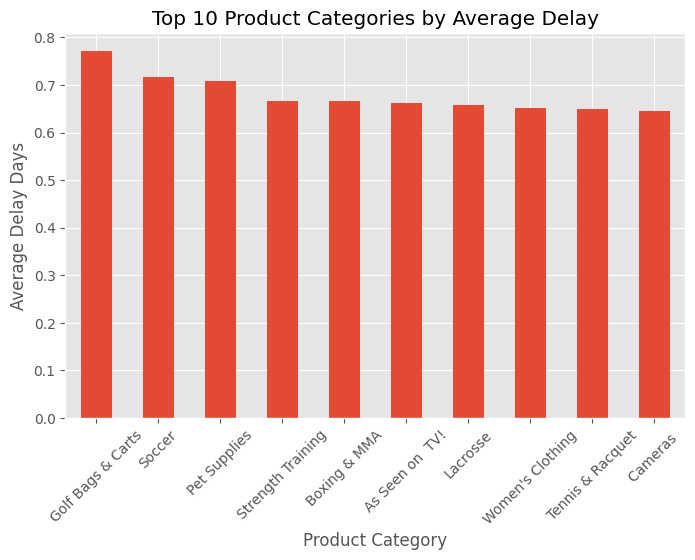

In [11]:
plt.figure(figsize=(8,5))
category_delay.plot(kind='bar')
plt.title("Top 10 Product Categories by Average Delay")
plt.xlabel("Product Category")
plt.ylabel ("Average Delay Days")
plt.xticks(rotation=45)
plt.show()

#Observation

The Golf category has the highest average delivery delay among the top 10 product categories.

#Business Insight

High-value or specialized product categories appear to require more delivery time, possibly due to supplier availability or inventory management.

#Recommendation

Review inventory planning and supplier performance for high-delay product categories such as Golf and Electronics.

In [12]:
# Which Customer Segment experiences the highest delivery delay?

segment_delay = (
    clean_data
    .groupby("Customer Segment")["Delay Days"]
    .mean()
    .sort_values(ascending=False)
)

segment_delay

Customer Segment
Home Office    0.577949
Consumer       0.564917
Corporate      0.560185
Name: Delay Days, dtype: float64

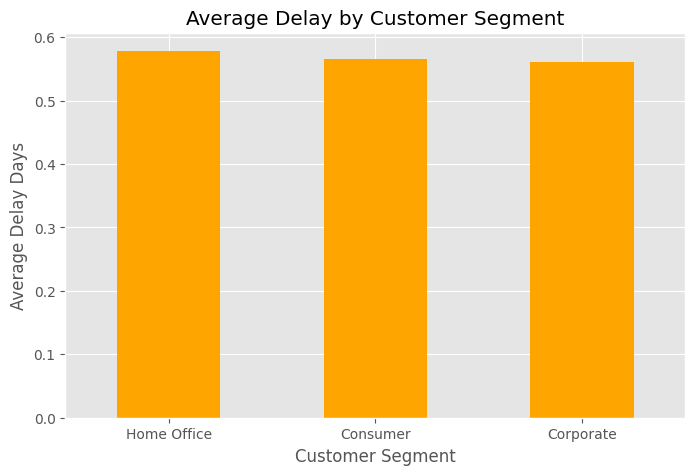

In [13]:
plt.figure(figsize=(8,5))

segment_delay.plot(kind="bar", color="orange")

plt.title("Average Delay by Customer Segment")

plt.xlabel("Customer Segment")

plt.ylabel("Average Delay Days")

plt.xticks(rotation=0)

plt.show()

In [14]:
# Which Market experiences the highest delivery delay?

market_delay = (
    clean_data
    .groupby("Market")["Delay Days"]
    .mean()
    .sort_values(ascending=False)
)

market_delay

Market
Europe          0.570843
Pacific Asia    0.569365
USCA            0.568859
Africa          0.560014
LATAM           0.557836
Name: Delay Days, dtype: float64

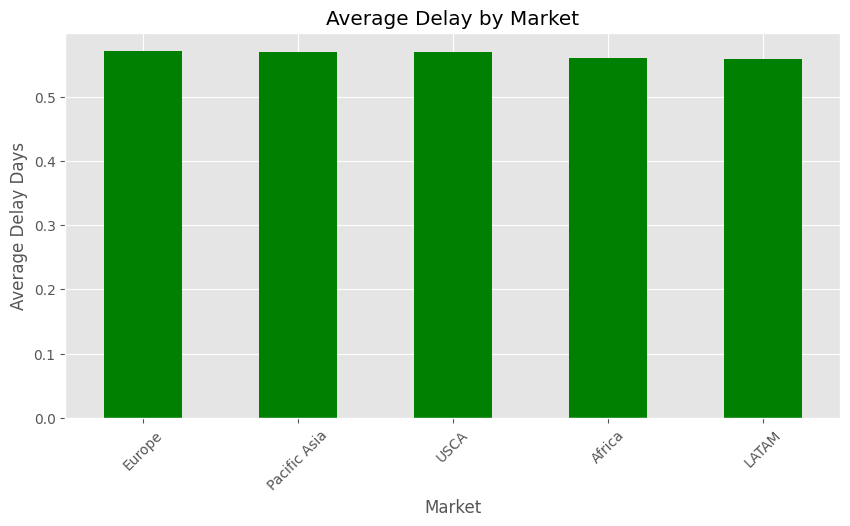

In [15]:
plt.figure(figsize=(10,5))

market_delay.plot(kind="bar", color="green")

plt.title("Average Delay by Market")

plt.xlabel("Market")

plt.ylabel("Average Delay Days")

plt.xticks(rotation=45)

plt.show()

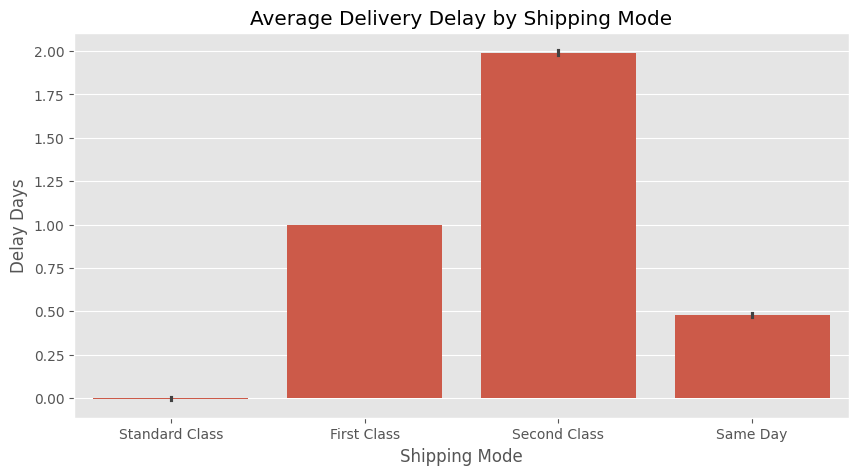

In [16]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=clean_data,
    x="Shipping Mode",
    y="Delay Days",
    estimator="mean"
)

plt.title("Average Delivery Delay by Shipping Mode")
plt.show()

In [17]:
# Which Month has the highest average delivery delay?

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_delay = (
    clean_data
    .groupby("Order Month")["Delay Days"]
    .mean()
    .reindex(month_order)
)

monthly_delay

Order Month
January      0.542462
February     0.591464
March        0.569873
April        0.565789
May          0.560437
June         0.575645
July         0.559107
August       0.568497
September    0.569792
October      0.555631
November     0.569413
December     0.564952
Name: Delay Days, dtype: float64

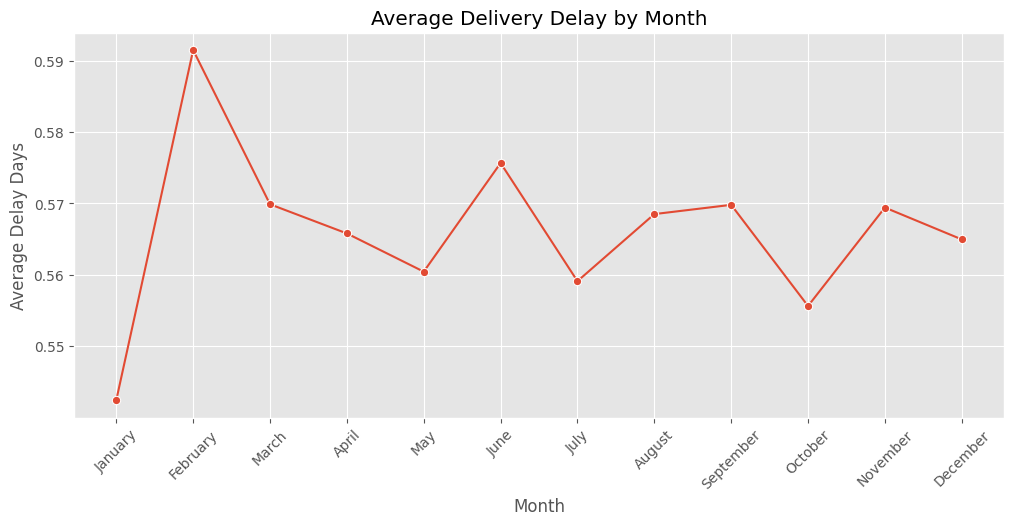

In [18]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly_delay.index,
    y=monthly_delay.values,
    marker="o"
)

plt.title("Average Delivery Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Delay Days")
plt.xticks(rotation=45)

plt.show()

In [19]:
# Which Weekday has the highest delivery delay?

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_delay = (
    clean_data
    .groupby("Order Day")["Delay Days"]
    .mean()
    .reindex(day_order)
)

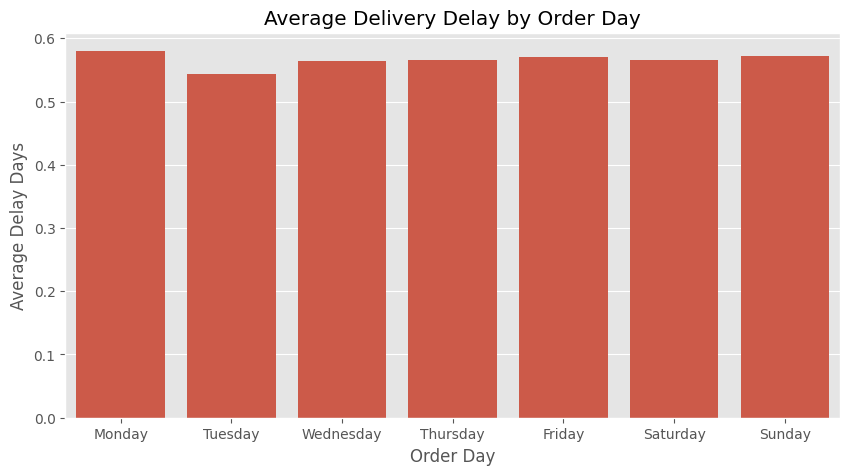

In [20]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=weekday_delay.index,
    y=weekday_delay.values
)

plt.title("Average Delivery Delay by Order Day")
plt.xlabel("Order Day")
plt.ylabel("Average Delay Days")

plt.show()

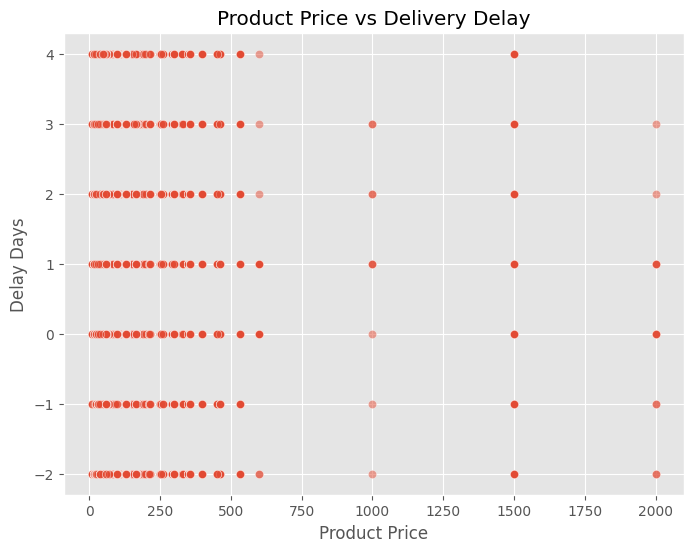

In [21]:
# Does Product Price affect Delivery Delay?


plt.figure(figsize=(8,6))

sns.scatterplot(
    data=clean_data,
    x="Product Price",
    y="Delay Days",
    alpha=0.5
)

plt.title("Product Price vs Delivery Delay")
plt.xlabel("Product Price")
plt.ylabel("Delay Days")

plt.show()

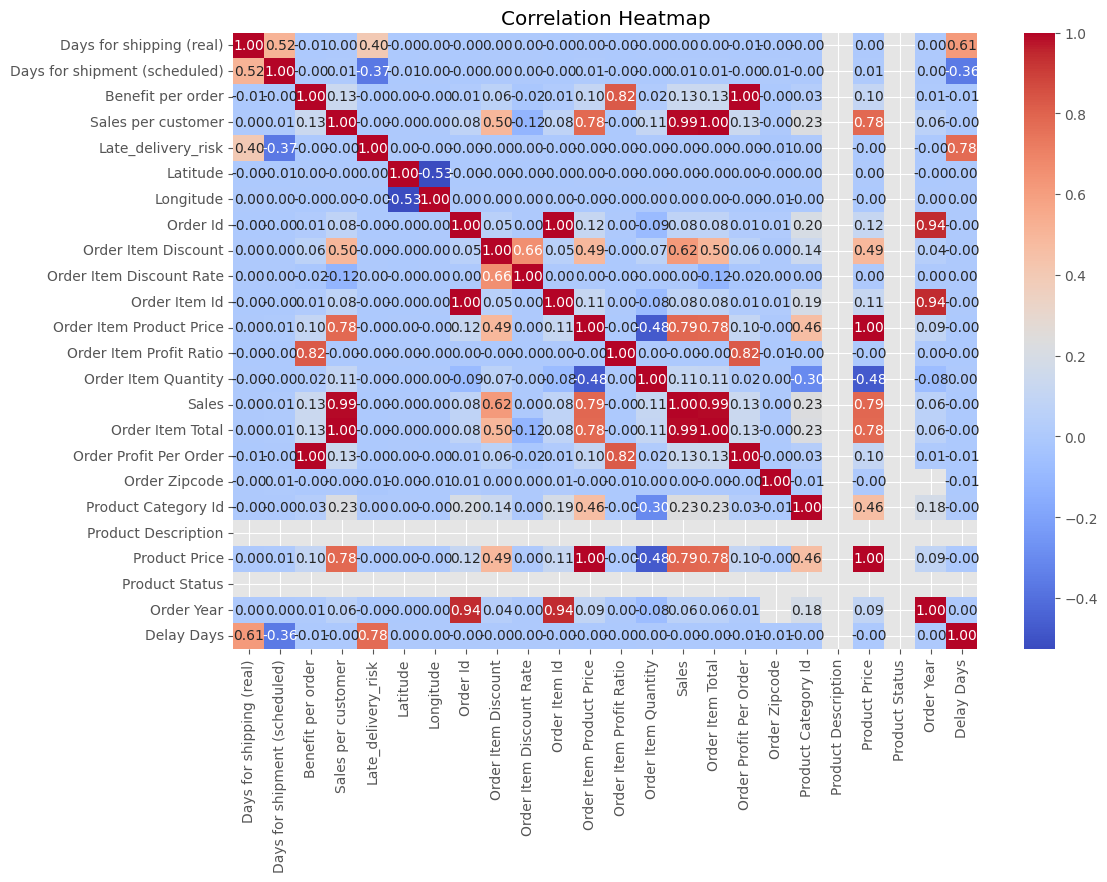

In [22]:
# Correlation Analysis

plt.figure(figsize=(12,8))

corr = clean_data.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

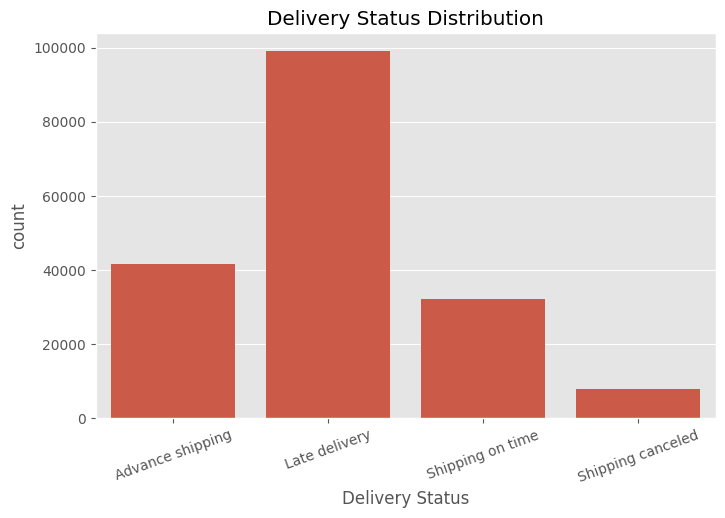

In [23]:
# Delivery Status Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=clean_data,
    x="Delivery Status"
)

plt.title("Delivery Status Distribution")

plt.xticks(rotation=20)

plt.show()

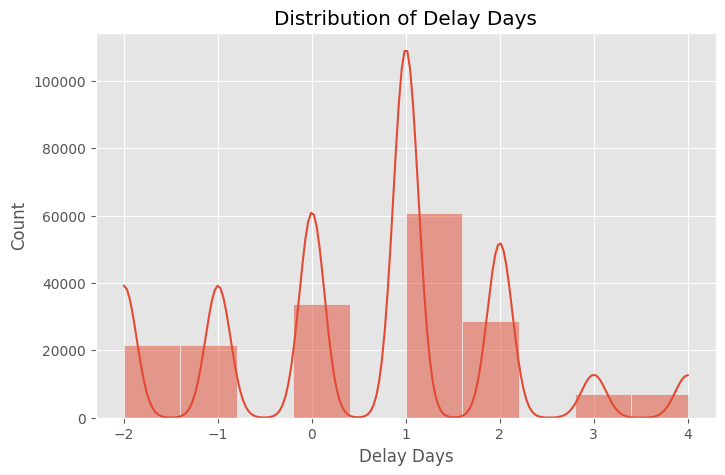

In [24]:
# Delay Days Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    clean_data["Delay Days"],
    bins=10,
    kde=True
)

plt.title("Distribution of Delay Days")

plt.show()

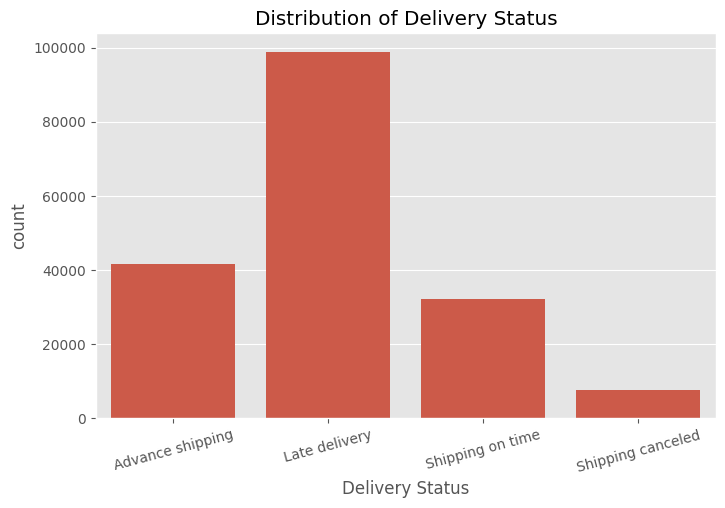

In [25]:
# Distribution of Delivery Status

plt.figure(figsize=(8,5))

sns.countplot(
    data=clean_data,
    x="Delivery Status"
)

plt.title("Distribution of Delivery Status")

plt.xticks(rotation=15)

plt.show()

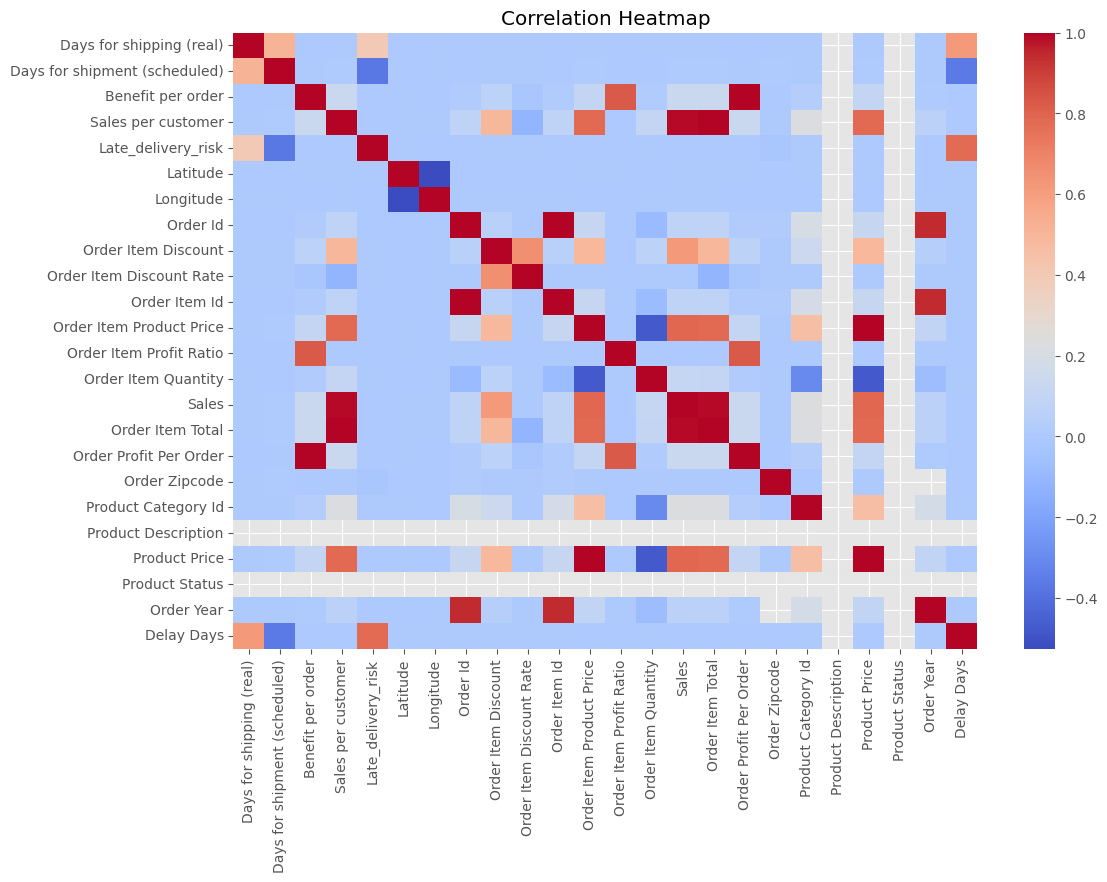

In [26]:
plt.figure(figsize=(12,8))

corr = clean_data.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(corr,cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()